<a href="https://colab.research.google.com/github/ELLLELEE/Deeplearning/blob/main/lec03%20%ED%8C%8C%EC%9D%B4%EC%8D%AC%20%EB%82%B4%EC%9A%A9%20%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* 우린 mnist문제를 풀것임
* 28*28개의 흑백 이미지 10개의 카테고리
* 60000개의 train 10000개의 test
* 먼저 데이터 확인하기


# 토치 가져와서 데이터 구분

In [1]:
# 토치 먼저 임포트 해주기

In [2]:
import torch

In [3]:
# 그리고 데이터 셋 가져오기

In [6]:
from torchvision import datasets, transforms

In [7]:
# 데이터 가져왔으면 train 데이터와 test 데이터 구분해주기

In [8]:
train_data = datasets.MNIST(root='./data', train=True, download=True)
test_data = datasets.MNIST(root='./data', train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.35MB/s]


In [15]:
train_images, train_target = train_data.data, train_data.targets
test_images, test_target = test_data.data, test_data.targets

In [12]:
type(train_data)

torchvision.datasets.mnist.MNIST

In [18]:
type(train_images)

torch.Tensor

In [20]:
print("Shape of train_images array : ", train_images.shape)

Shape of train_images array :  torch.Size([60000, 28, 28])


In [21]:
# trian_images 는 60000개의 샘플과 3차원으로 이루어져있음

In [23]:
train_images[10]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118, 219,
         166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254,
         254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [26]:
train_images[10].shape

torch.Size([28, 28])

In [29]:
train_target

tensor([5, 0, 4,  ..., 5, 6, 8])

In [31]:
train_target.shape

torch.Size([60000])

# 데이터 이미지로 생성

In [32]:
# 데이터 분류가 끝났다면 한번 이미지로 생성
# cm -> 컬러맵 모음, 색깔설정용
# imshow() -> 이미지를 화면에 그림으로 출력
# cm.binary -> 흑백 컬러뱁(0 = 검정, 1=화이트)

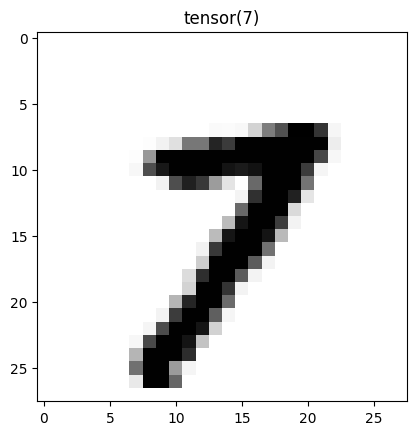

In [38]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def visualize_mnist(image, target):
  plt.imshow(image,cm.binary)
  plt.title(target)
  plt.show()

visualize_mnist(train_images[40000], train_target[40000])

In [ ]:
# 이제 잘 분리된 데이터들을 신경망에 입력할 것임
# 학습이 끝나면 test를 해서 결과가 맞는지 확인할 것임


# 인공 신경망 만들기

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [41]:
# 먼저 nn와 F 임포트 해주기

In [43]:
class SimpleNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(28*28, 512)
    self.fc2 = nn.Linear(512,10)

  def forward(self,x):
    x = self.fc1(x)
    x = F.relu(x)
    x = self.fc2(x)
    return x


In [44]:
# 신경망 만드는 방법
# 1) class SimpleNN(nn.Module) -> nn.Module 상속 -> 신경망 모델 동작하게
# 2) init 정의 -> super().__init__() -> 부모(nn,Module) 초기화
# 3) self.fc1 = nn.Linear(756, 512) -> 입력 이미지 -> 512차원으로 변환,
# * nn.Linear -> y = Wx+b
# 4) self.fc2 = nn.Linear(512,10) -> 512 -> 10으로 변환

In [45]:
# forward(데이터 흐름)
# 1) forward 함수 정의 입력 x가 모델을 어떻게 통과하는지 정의
# 2) x = self.fc1(x) -> 선형변환 거침
# 3) x = F.ReLU(x) -> activation function -> 음수 제거 비선형성 추가
# 4) x = self.fc2(x) -> 두번째 선형 변환

In [46]:
model = SimpleNN()

In [47]:
print(model)

SimpleNN(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [49]:
# 모델의 핵심구성은 레이어이다
# 레이어는 입력된 데이터로부터 특징을 추출한다
# 마지막 레이어(fc2) 는 10개의 출력층으로 10개의 원시 점수(logit)을 만든다
# 그리고 이 값들을 cross함수나 softmax함수에 넣어 확률로 변환한다

In [50]:
# 모델을 학습 가능하게 만들기 위한 3가지
# 1) 손실함수
# 2) 옵티마이저
# 3) 성능확인 지표

# 손실 함수 정의


In [57]:
is_cuda = torch.cuda.is_available()
device = torch.device('cuda' if is_cuda else 'cpu')
print('Current device is', device)

Current device is cpu


In [ ]:
# 먼저 손실함수 정의 하기

In [56]:
model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-3)

def accuracy(logits, target):
    preds = torch.argmax(logits, dim=1)
    return (preds == target).float().mean()

In [59]:
# 1) model먼저 가져오기 .to(device) -> 가져온 device가 계산
# 2) criterion = nn.CrossEntropyLoss() 손실 함수 정의 -> 모델의 출력갑과 라벨 비교
# 3) torch.optim.RMSprop 모델 정의
# 4) model.parameters() -> ()에 들어있는 가중치들을 학습하면서 업데이트 lr=1e-3 학습률

In [60]:
# 1) def accuracy(logits, target): -> 정확도 계산하는 함수 모델출력(logit) 과 라벨
# 2)preds = torch.argmax(logits, dim=1) ->각 샘플마다 가장 큰 값의 위치를 뽑음.
# * dim=1 -> 각 이미지 안에서 가로방향 최대값
# 3) return (preds == target).float().mean() -> true false를 1,0으로 뽑고 평균


# 데이터 로드로 불러오기



In [61]:
# 데이터를 조금씩 나눠서 (batch)가져오면서 처리
# 가져올때마다 전처리도 같이 진행

In [62]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [63]:
# 데이터를 전처리하는 방법
# 1) 먼저 ToTensor 거쳐서 차원을 바꿔줌 -> (1,28,28)
# 2) 그 다음 Lambda를 거쳐서 28*28 = (784,) 로 길게 늘려줌
# -> 이 값은 위에 self.fc1 = nn.Linear(784,512) 여기로 넣기 위함
# 3) 그래서 우린 Totensor 와 Lambda 함수를 정의해주기 위해 먼저 설정

In [68]:
train_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t:t.view(-1))
])
test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t:t.view(-1))
])
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=train_tfms)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=test_tfms)

In [72]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle= True,  num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# 데이터 학습 코드

In [71]:
import time
start = time.time()

In [84]:
import time
start = time.time()

model.train()
for epoch in range(3):
  total_loss = 0.0
  total_acc = 0.0
  n_batches = 0
  for data, target in train_loader:
    data = data.to(device)
    target = target.to(device)

    optimizer.zero_grad()
    logits = model(data)
    loss = criterion(logits, target)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total_acc += accuracy(logits, target)
    n_batches += 1

  train_loss = running_loss / n_batches
  train_acc  = running_acc  / n_batches
  print("Epoch : {}\tLoss : {:3f}\tAcc : {:3f}".format(epoch, train_loss, train_acc))
print('Training time:', time.time()-start)









/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch : 0	Loss : 0.022012	Acc : 0.992870
Epoch : 1	Loss : 0.022012	Acc : 0.992870
Epoch : 2	Loss : 0.022012	Acc : 0.992870
Training time: 42.12910223007202


## 모델 학습 과정
1) model.train -> 학습모드로 변경
2) epoch 설정 -> 반복횟수
3) 데이터 로더에서 데이터 가져오기
4) 데이터 디바이스에 넣어주기
5) optimizer.zero_grad() -> 이전 그레이 값 리셋
6) logit값 구하기 모델에 데이터 넣어서 모델 예측
7) 구한 logit값으로 loss구하기
8) loss.backward를 통해 가중치 다시 계산
9) backward로 구한 그레디언트 이용해서 가중치 다시 구함
* .item() -> 숫자값 꺼내주기 굵은 텍스트

In [87]:
model.eval()
correct = 0
for data, target in test_loader:
    data, target = data.to(device), target.to(device)
    output = model(data)
    prediction = output.data.max(1)[1]
    correct += prediction.eq(target.data).sum()
print('Test set Accuracy : {:.2f}%'.format(100. * correct / len(test_loader.dataset)))

Test set Accuracy : 98.16%


## 모델 평가 과정


1.   model.eval() -> 평가모드로 변경
2.   output = model(data) -> 값 예측
3.   prediction = output.data.max(1)[1]

-> output.shape -> (배치크기, 10)

-> max(1) = dim =1 -> 각 이미지마다 10개중 가장 큰 값

-> 각 행에서 최대값을 찾고 그 값의 인덱스가 이미지라고 예측

-> [3] 이 최대값이면 숫자 3이라고 예측

-> max(1)[0] -> 최대값 , max(1)[1] -> 최대값의 위치

-> 우린 인덱스가 중요하기때문에 [1]붙임

-> output.argmax(dim=1) 대체 가능




